In [1]:
import os
import re
import glob
import cv2
import dlib
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


Archivo 'rutas_emociones.txt' creado correctamente.
Counter({'Sorpresa': 83, 'Felicidad': 69, 'Disgusto': 60, 'Enojo': 45, 'Tristeza': 28, 'Miedo': 25, 'Desprecio': 18})


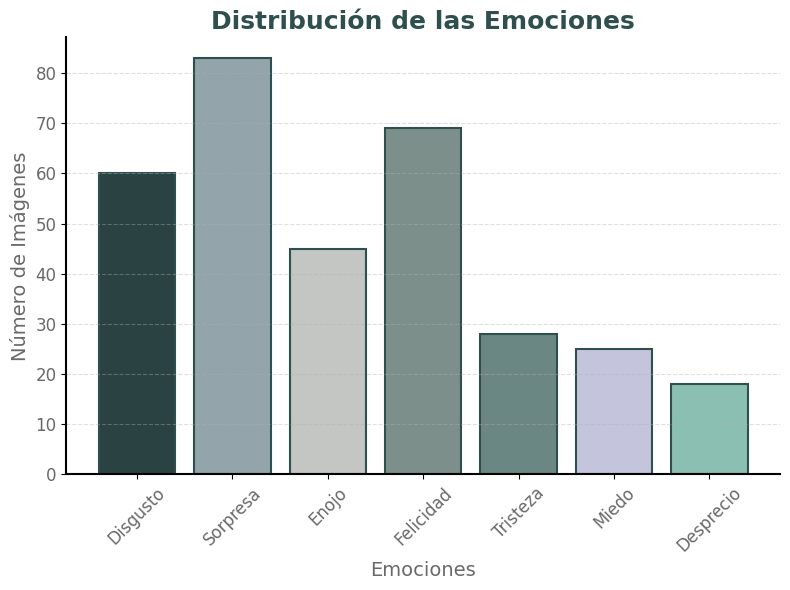

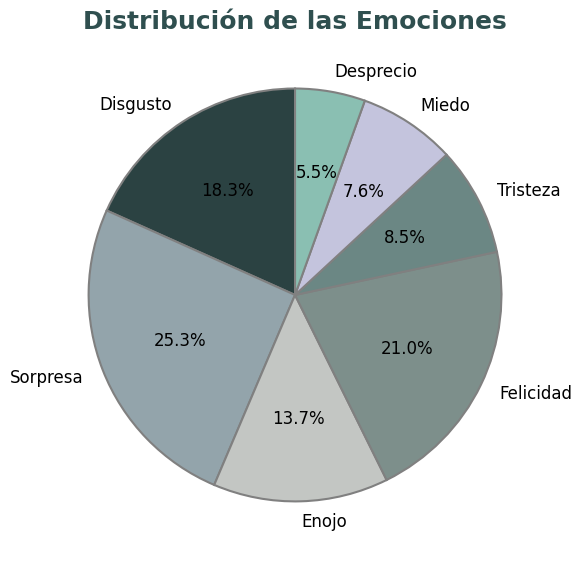

In [2]:
# Función para ordenar archivos numéricamente
def ordenar_numeros(valor):
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = map(int, partes[1::2])
    return partes

# Función para recolectar números de emoción desde archivos .txt
def recoger_datos_emocion(dir_raiz):
    datos = []
    for dirpath, dirnames, filenames in os.walk(dir_raiz):
        dirnames.sort(key=ordenar_numeros)
        filenames.sort()
        for archivo in filenames:
            if archivo.endswith('.txt'):
                ruta = os.path.join(dirpath, archivo)
                try:
                    with open(ruta, 'r') as f:
                        contenido = f.read().strip()
                        match = re.search(r'\d+', contenido)
                        if match:
                            numero = match.group(0)
                            datos.append(numero)
                except Exception as e:
                    print(f"Error leyendo {ruta}: {e}")
    return datos

# Guardar los números de emoción en un archivo
directorio_emociones = "Emotion"
datos_txt = recoger_datos_emocion(directorio_emociones)

if not datos_txt:
    print("No se encontraron archivos .txt en el directorio.")
else:
    with open('rutas_emociones.txt', 'w') as archivo:
        for numero in datos_txt:
            archivo.write(f"{numero}\n")
    print("Archivo 'rutas_emociones.txt' creado correctamente.")

# Leer los números de emoción desde el archivo
with open('rutas_emociones.txt', 'r') as f:
    numeros_emociones = [int(linea.strip()) for linea in f]

# Mapear los números a nombres de emociones
etiquetas_emocion = {
    0: 'Neutral',
    1: 'Enojo',
    2: 'Desprecio',
    3: 'Disgusto',
    4: 'Miedo',
    5: 'Felicidad',
    6: 'Tristeza',
    7: 'Sorpresa'
}
emociones = [etiquetas_emocion.get(num, 'Desconocido') for num in numeros_emociones]

# Contar la frecuencia de cada emoción
conteo_emociones = Counter(emociones)
print(conteo_emociones)

# Colores  para las gráficas
colores = ['#2B4242', '#93A4AB', '#C3C6C3', '#7D8F8B', '#6B8784', '#C4C4DD', '#8ABFB2', '#01332B']

# Gráfico de barras para la distribución de emociones
plt.figure(figsize=(8, 6))
barras = plt.bar(conteo_emociones.keys(), conteo_emociones.values(), color=colores)
plt.title('Distribución de las Emociones', fontsize=18, fontweight='bold', color='#2F4F4F')
plt.xlabel('Emociones', fontsize=14, color='#696969')
plt.ylabel('Número de Imágenes', fontsize=14, color='#696969')
plt.xticks(rotation=45, fontsize=12, color='#696969')
plt.yticks(fontsize=12, color='#696969')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# ajustar la apariencia del gráfico
for barra in barras:
    barra.set_edgecolor('#2F4F4F')
    barra.set_linewidth(1.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_linewidth(1.5)
plt.gca().spines['bottom'].set_linewidth(1.5)
plt.tight_layout()
plt.show()

# Gráfico circular para la distribución de emociones
plt.figure(figsize=(6, 6))
plt.pie(conteo_emociones.values(), labels=conteo_emociones.keys(), autopct='%1.1f%%',
        colors=colores, startangle=90, wedgeprops={'edgecolor': 'gray', 'linewidth': 1.5},
        textprops={'fontsize': 12, 'color': 'black'})
plt.title('Distribución de las Emociones', fontsize=18, fontweight='bold', color='#2F4F4F')
plt.tight_layout()
plt.show()


Error leyendo Emotion/S005/001/.ipynb_checkpoints/S005_001_00000011_emotion-checkpoint.txt: [Errno 2] No such file or directory: 'cohn-kanade-images/S005/001/.ipynb_checkpoints'
Emoción: Enojo
  Total de puntos: 3060
  Fuera de bigotes: Conteo = 85, Porcentaje = 2.78%
  Dentro de cuartiles: Conteo = 1001, Porcentaje = 32.71%
  En bigotes: Conteo = 1974, Porcentaje = 64.51%

Emoción: Desprecio
  Total de puntos: 1224
  Fuera de bigotes: Conteo = 46, Porcentaje = 3.76%
  Dentro de cuartiles: Conteo = 337, Porcentaje = 27.53%
  En bigotes: Conteo = 841, Porcentaje = 68.71%

Emoción: Disgusto
  Total de puntos: 4012
  Fuera de bigotes: Conteo = 157, Porcentaje = 3.91%
  Dentro de cuartiles: Conteo = 1273, Porcentaje = 31.73%
  En bigotes: Conteo = 2582, Porcentaje = 64.36%

Emoción: Miedo
  Total de puntos: 1700
  Fuera de bigotes: Conteo = 104, Porcentaje = 6.12%
  Dentro de cuartiles: Conteo = 598, Porcentaje = 35.18%
  En bigotes: Conteo = 998, Porcentaje = 58.71%

Emoción: Felicidad
  

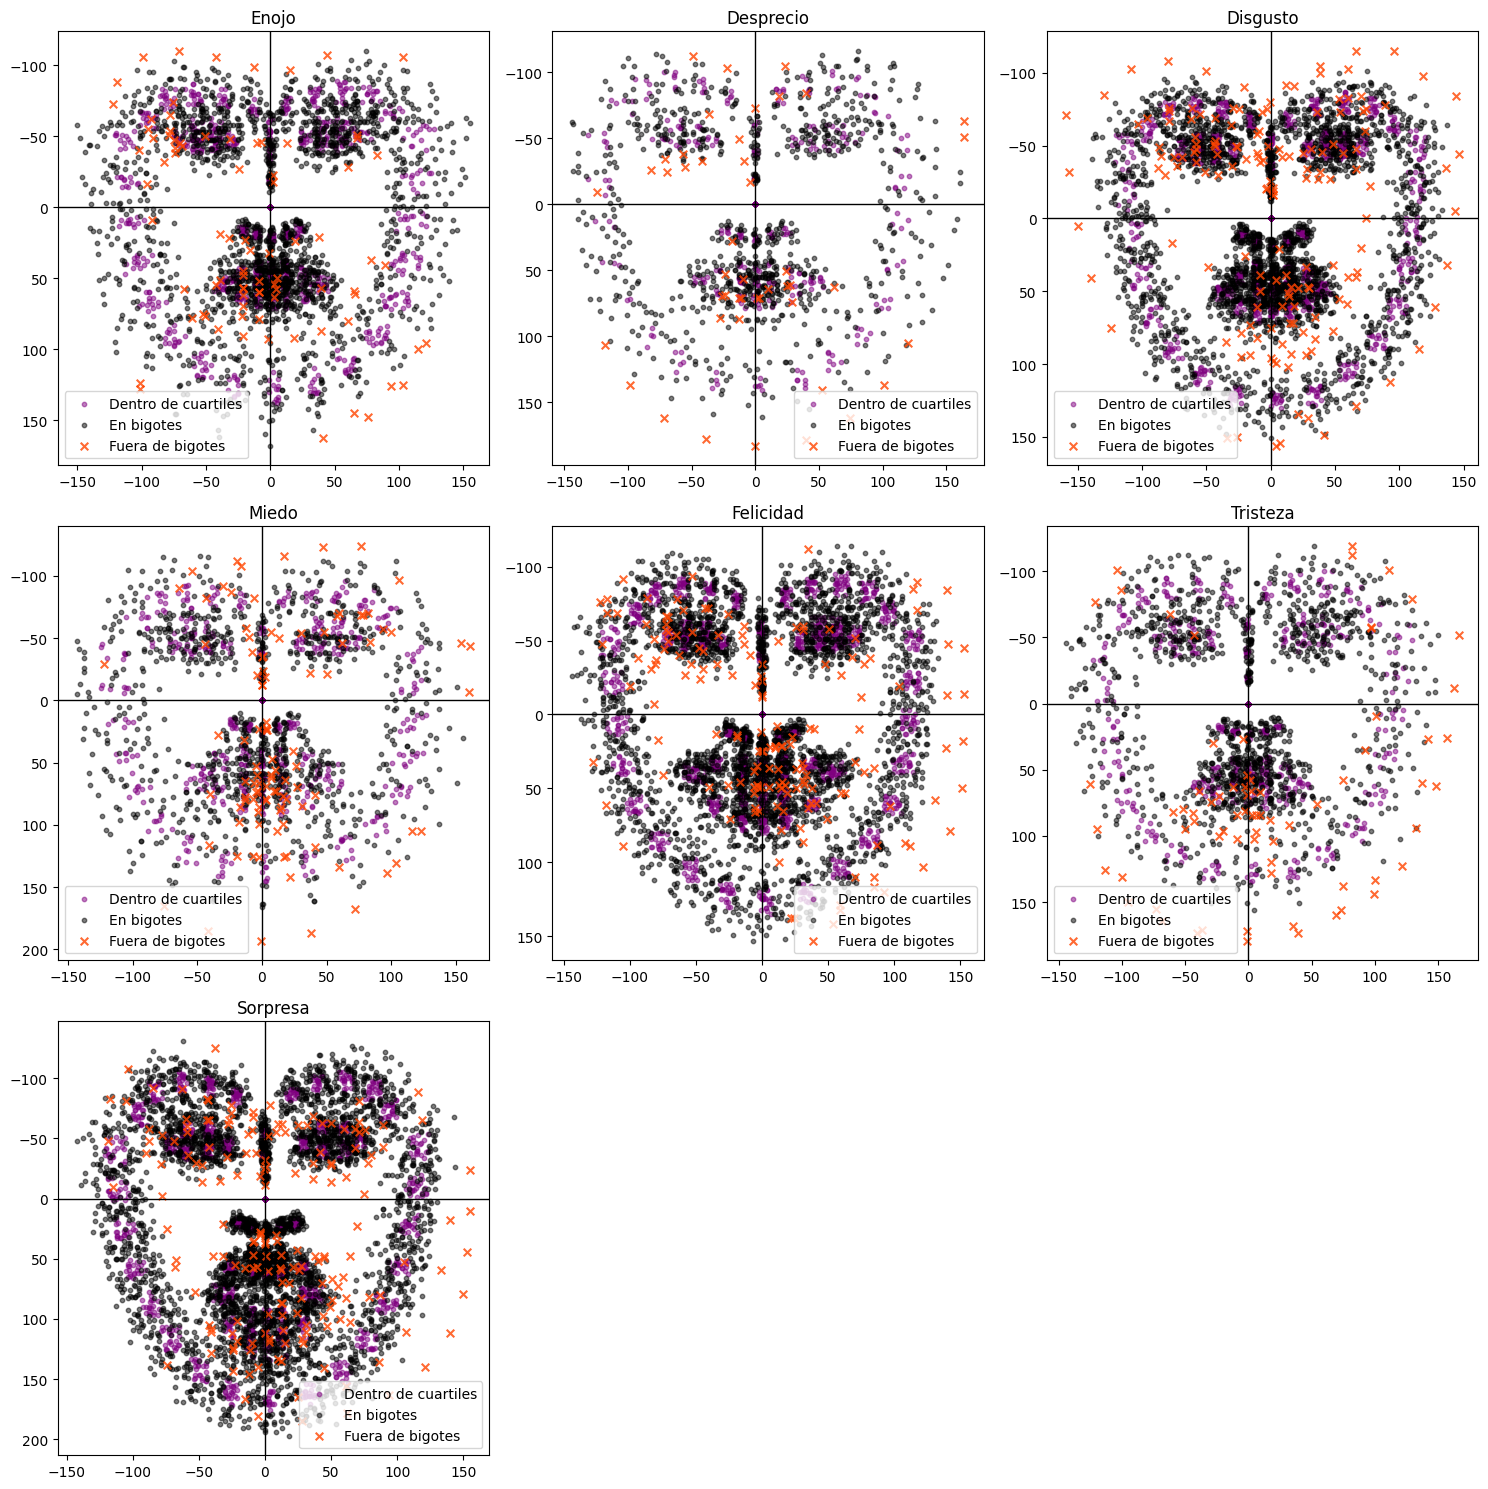

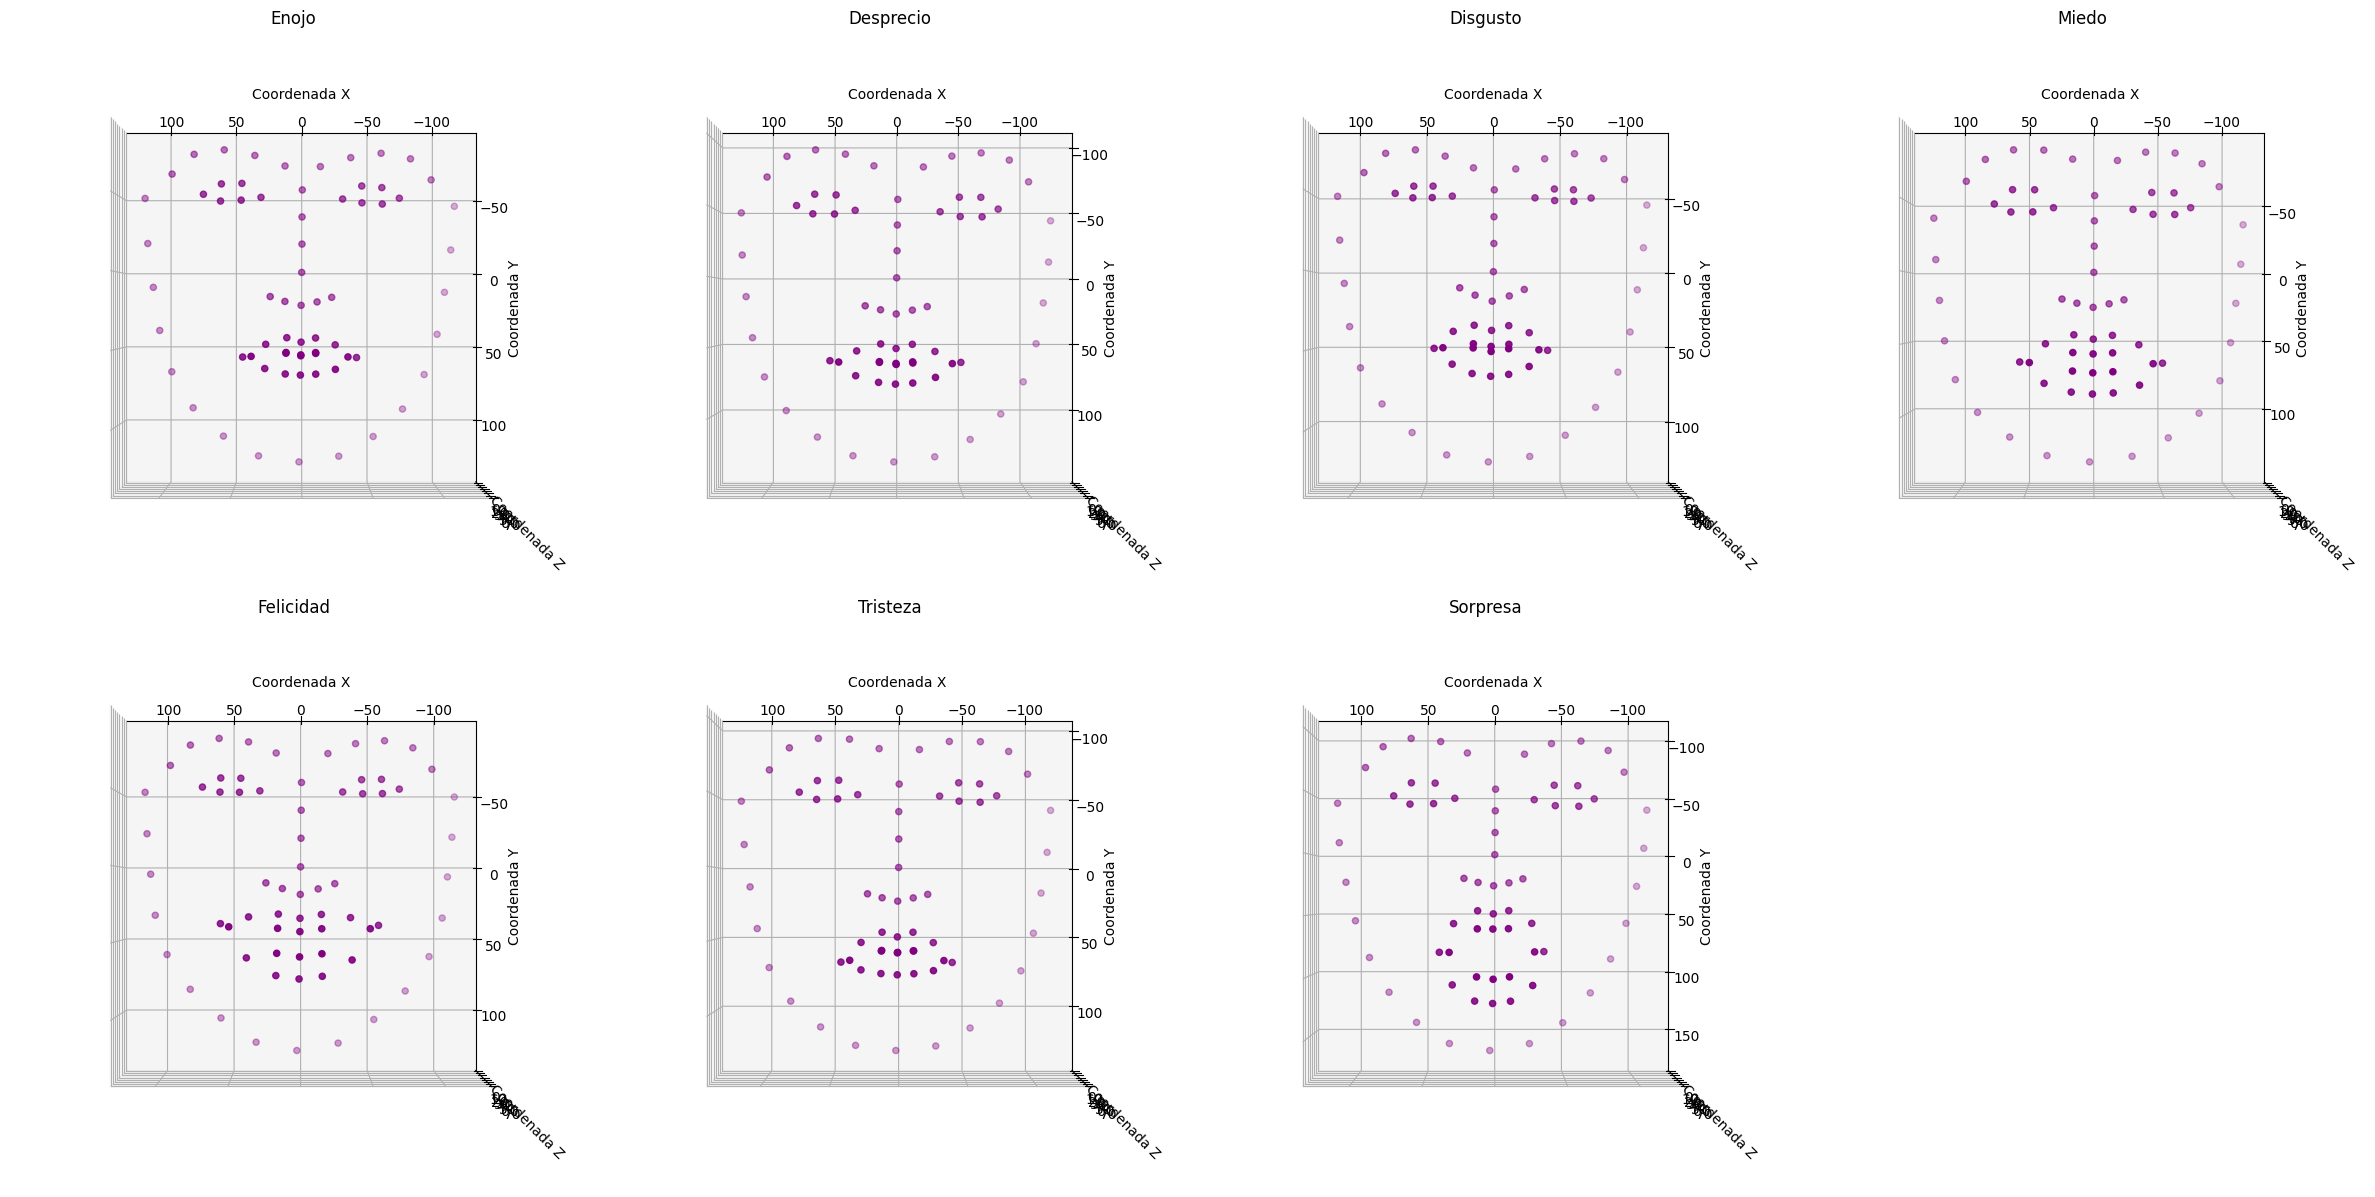

In [3]:
# Inicializar detector de rostros y predictor de puntos faciales
det = dlib.get_frontal_face_detector()
pred = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

emo_nom = {
    1: 'Enojo',
    2: 'Desprecio',
    3: 'Disgusto',
    4: 'Miedo',
    5: 'Felicidad',
    6: 'Tristeza',
    7: 'Sorpresa'
}

def ordenar_numerico(valor):
    # Ordenar cadenas numéricamente
    numeros = re.compile(r'(\d+)')
    partes = numeros.split(valor)
    partes[1::2] = list(map(int, partes[1::2]))
    return partes

def obtener_datos_txt(raiz):
    # Obtener rutas de imágenes y emociones desde archivos .txt
    datos = []
    for dir_actual, subdirs, archivos in os.walk(raiz):
        subdirs.sort(key=ordenar_numerico)
        archivos.sort(key=ordenar_numerico)
        for archivo in archivos:
            if archivo.endswith('.txt'):
                ruta_archivo = os.path.join(dir_actual, archivo)
                try:
                    with open(ruta_archivo, 'r') as f:
                        numero = f.read().strip()
                    try:
                        numero = int(float(numero))
                    except ValueError as e:
                        print(f"Error al convertir el número en {ruta_archivo}: {e}")
                        continue

                    # Construir ruta de imagen correspondiente
                    ruta_relativa = os.path.relpath(dir_actual, raiz)
                    dir_imagen = os.path.join('cohn-kanade-images', ruta_relativa)
                    archivos_imagen = [f for f in os.listdir(dir_imagen) if f.endswith('.png')]
                    archivos_imagen.sort(key=ordenar_numerico)
                    if archivos_imagen:
                        ruta_imagen = os.path.join(dir_imagen, archivos_imagen[-1])  # Última imagen
                        datos.append((ruta_imagen, numero))  # Añadir ruta de imagen y emoción
                    else:
                        print(f"No se encontraron imágenes en {dir_imagen}")
                except Exception as e:
                    print(f"Error leyendo {ruta_archivo}: {e}")
    return datos

def extraer_puntos(ruta_imagen):
    # Extraer puntos faciales de una imagen
    imagen = cv2.imread(ruta_imagen)
    if imagen is None:
        print(f"No se pudo cargar la imagen {ruta_imagen}")
        return None

    rostros = det(imagen)
    if len(rostros) == 0:
        print(f"No se detectaron rostros en {ruta_imagen}")
        return None

    for rostro in rostros:
        puntos = pred(imagen, rostro)
        lista_puntos = [(puntos.part(n).x, puntos.part(n).y) for n in range(68)]
        return lista_puntos

def centrar_puntos(puntos):
    # Centrar puntos faciales en la nariz
    nariz = puntos[30]  # Índice 30 corresponde a la nariz
    puntos_centrados = [(x - nariz[0], y - nariz[1]) for x, y in puntos]
    return puntos_centrados

def calcular_categorias_puntos(puntos_por_emocion):
    # Calcular categorías de puntos y estadísticas por emoción
    categorias_por_emocion = {}
    stats_por_emocion = {}

    for emocion, lista_puntos in puntos_por_emocion.items():
        if lista_puntos:
            array_puntos = np.array(lista_puntos)
            Q1 = np.percentile(array_puntos, 25, axis=0)
            Q3 = np.percentile(array_puntos, 75, axis=0)
            IQR = Q3 - Q1  # Rango intercuartílico

            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            outliers = (array_puntos < limite_inferior) | (array_puntos > limite_superior)
            dentro = (array_puntos >= Q1) & (array_puntos <= Q3)

            mascara_outliers = outliers.any(axis=2)
            mascara_dentro = dentro.all(axis=2)
            mascara_bigotes = (~mascara_outliers) & (~mascara_dentro)

            categorias = np.empty((array_puntos.shape[0], array_puntos.shape[1]), dtype=object)
            categorias[mascara_outliers] = 'Fuera de bigotes'
            categorias[mascara_dentro] = 'Dentro de cuartiles'
            categorias[mascara_bigotes] = 'En bigotes'

            categorias_por_emocion[emocion] = categorias

            # Calcular conteos y porcentajes
            total_puntos = array_puntos.size // 2  # Total de puntos (cada punto tiene x e y)
            num_fuera = np.sum(mascara_outliers)
            num_dentro = np.sum(mascara_dentro)
            num_bigotes = np.sum(mascara_bigotes)

            porcentaje_fuera = (num_fuera / total_puntos) * 100
            porcentaje_dentro = (num_dentro / total_puntos) * 100
            porcentaje_bigotes = (num_bigotes / total_puntos) * 100

            stats_por_emocion[emocion] = {
                'Total Puntos': total_puntos,
                'Fuera de bigotes': {'Conteo': num_fuera, 'Porcentaje': porcentaje_fuera},
                'Dentro de cuartiles': {'Conteo': num_dentro, 'Porcentaje': porcentaje_dentro},
                'En bigotes': {'Conteo': num_bigotes, 'Porcentaje': porcentaje_bigotes}
            }

    return categorias_por_emocion, stats_por_emocion

def prom_pts(pts_por_emo):
    # Calcular promedio de puntos por emoción
    proms = {}
    for emo, lst_pts in pts_por_emo.items():
        if lst_pts:
            arr_pts = np.array(lst_pts)
            promedio = np.mean(arr_pts, axis=0)
            proms[emo] = promedio
    return proms

def graf_prom_pts_3d(proms):
    # Graficar promedios de puntos en 3D por emoción
    emos = list(proms.keys())
    num_emos = len(emos)
    n_cols = 4
    n_rows = (num_emos + n_cols - 1) // n_cols

    fig = plt.figure(figsize=(n_cols * 6, n_rows * 6))

    for idx, emo in enumerate(emos):
        promedio = proms[emo]
        xs = promedio[:, 0]
        ys = promedio[:, 1]
        zs = np.arange(68)

        ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='3d')
        ax.scatter(xs, ys, zs, color='purple', s=20)

        ax.set_title(f'{emo_nom.get(emo, emo)}', fontsize=12)
        ax.set_xlabel('Coordenada X')
        ax.set_ylabel('Coordenada Y')
        ax.set_zlabel('Coordenada Z')
        ax.view_init(elev=90, azim=90)

    plt.tight_layout()
    plt.show()

def graf_pts_cat(pts_por_emo, cat_por_emo):
    # Graficar puntos con categorías en subplots por emoción
    emos = [emo for emo, lst_pts in pts_por_emo.items() if lst_pts]
    num_emos = len(emos)
    n_cols = 3
    n_rows = (num_emos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
    axes = axes.flatten()

    for idx, (emo, ax) in enumerate(zip(emos, axes)):
        lst_pts = pts_por_emo[emo]
        cats = cat_por_emo[emo]
        arr_pts = np.array(lst_pts)

        idx_dentro = np.where(cats == 'Dentro de cuartiles')
        idx_big = np.where(cats == 'En bigotes')
        idx_fuera = np.where(cats == 'Fuera de bigotes')

        coord_dentro = arr_pts[idx_dentro[0], idx_dentro[1], :]
        coord_big = arr_pts[idx_big[0], idx_big[1], :]
        coord_fuera = arr_pts[idx_fuera[0], idx_fuera[1], :]

        ax.scatter(coord_dentro[:, 0], coord_dentro[:, 1], s=10, color='purple', alpha=0.5, label='Dentro de cuartiles')
        ax.scatter(coord_big[:, 0], coord_big[:, 1], s=10, color='black', alpha=0.5, label='En bigotes')
        ax.scatter(coord_fuera[:, 0], coord_fuera[:, 1], s=30, color='Orangered', alpha=0.8, label='Fuera de bigotes', marker='x')

        ax.invert_yaxis()
        ax.axhline(0, color='black', linewidth=1)
        ax.axvline(0, color='black', linewidth=1)
        ax.set_title(f"{emo_nom.get(emo, emo)}")
        ax.legend()

    for idx in range(num_emos, len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

# Directorio de emociones e imágenes
dir_emo = "Emotion"
datos_txt = obtener_datos_txt(dir_emo)

if datos_txt:
    pts_por_emo = {i: [] for i in range(1, 8)}

    for ruta_img, emo in datos_txt:
        pts = extraer_puntos(ruta_img)
        if pts:
            pts_cen = centrar_puntos(pts)
            pts_por_emo[emo].append(pts_cen)

    pts_por_emo = {k: v for k, v in pts_por_emo.items() if v}

    cat_por_emo, stats_por_emo = calcular_categorias_puntos(pts_por_emo)

    for emo, stats in stats_por_emo.items():
        print(f"Emoción: {emo_nom.get(emo, emo)}")
        print(f"  Total de puntos: {stats['Total Puntos']}")
        for categoria, valores in stats.items():
            if categoria != 'Total Puntos':
                print(f"  {categoria}: Conteo = {valores['Conteo']}, Porcentaje = {valores['Porcentaje']:.2f}%")
        print()

    graf_pts_cat(pts_por_emo, cat_por_emo)

    proms = prom_pts(pts_por_emo)

    graf_prom_pts_3d(proms)
else:
    print("No se encontraron datos de emociones para procesar.")


Error leyendo Emotion/S005/001/.ipynb_checkpoints/S005_001_00000011_emotion-checkpoint.txt: [Errno 2] No such file or directory: 'cohn-kanade-images/S005/001/.ipynb_checkpoints'
Distribución en Train: Counter({7: 66, 5: 55, 3: 47, 1: 36, 6: 22, 4: 20, 2: 15})
Distribución en Test:  Counter({7: 17, 5: 14, 3: 12, 1: 9, 6: 6, 4: 5, 2: 3})


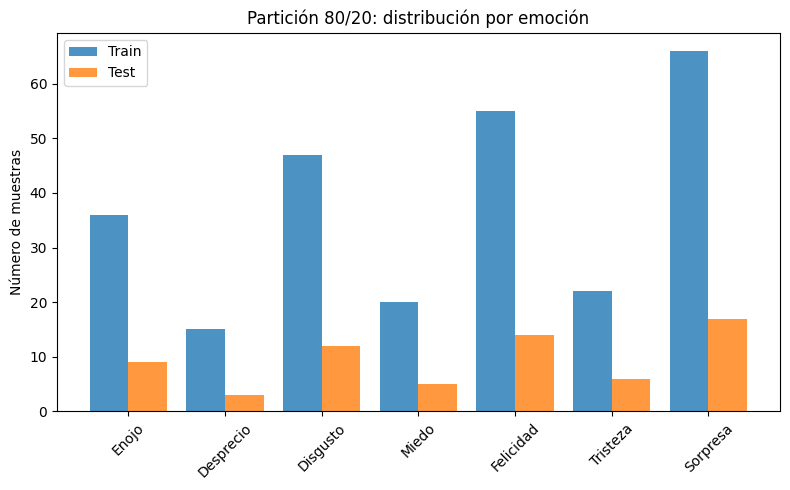

In [8]:
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de haber definido/importado antes estas funciones y variables:
#   - obtener_datos_txt(raiz): devuelve lista de tuplas (ruta_imagen, etiqueta_emoción)
#   - extraer_puntos(ruta_imagen): devuelve lista de 68 landmarks [(x,y),…] o None
#   - centrar_puntos(puntos): centra los landmarks en la nariz
#   - dir_emo: string con el path al directorio "Emotion"

# 0) Construir X e y
datos_txt = obtener_datos_txt(dir_emo)

X_list = []
y_list = []
for ruta_imagen, emo in datos_txt:
    pts = extraer_puntos(ruta_imagen)
    if pts is None:
        continue
    pts_c = centrar_puntos(pts)
    X_list.append(np.array(pts_c).flatten())  # vector 136-dim
    y_list.append(emo)

# Convertir a arrays
X = np.vstack(X_list)        # shape (n_muestras, 136)
y = np.array(y_list, dtype=int)

# Mapeo de etiquetas a nombres (para el plot)
emo_nom = {
    1: 'Enojo',
    2: 'Desprecio',
    3: 'Disgusto',
    4: 'Miedo',
    5: 'Felicidad',
    6: 'Tristeza',
    7: 'Sorpresa'
}

# 1) División estratificada 80% / 20%
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2) Mostrar conteos por emoción
cnt_tr = Counter(y_train)
cnt_te = Counter(y_test)
print("Distribución en Train:", cnt_tr)
print("Distribución en Test: ", cnt_te)

# 3) Gráfico comparativo
labels = sorted(cnt_tr.keys())  # [1,2,…,7]
train_counts = [cnt_tr[l] for l in labels]
test_counts  = [cnt_te[l] for l in labels]
x = np.arange(len(labels))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, train_counts, width=0.4, label='Train', alpha=0.8)
plt.bar(x + 0.2, test_counts,  width=0.4, label='Test',  alpha=0.8)
plt.xticks(x, [emo_nom[l] for l in labels], rotation=45)
plt.ylabel('Número de muestras')
plt.title('Partición 80/20: distribución por emoción')
plt.legend()
plt.tight_layout()
plt.show()


Accuracy en Test (PCA=40, C=130, γ=0.0002): 0.8788

Reporte de clasificación:

              precision    recall  f1-score   support

       Enojo       1.00      0.67      0.80         9
   Desprecio       0.60      1.00      0.75         3
    Disgusto       0.91      0.83      0.87        12
       Miedo       1.00      0.60      0.75         5
   Felicidad       0.82      1.00      0.90        14
    Tristeza       0.71      0.83      0.77         6
    Sorpresa       1.00      1.00      1.00        17

    accuracy                           0.88        66
   macro avg       0.86      0.85      0.83        66
weighted avg       0.90      0.88      0.88        66



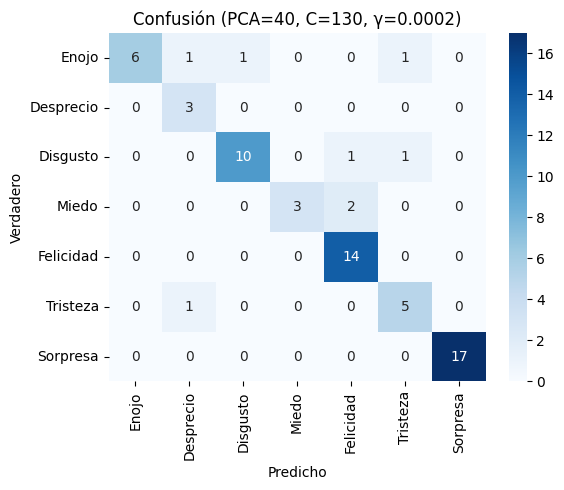

In [18]:
#Estos fueron los valores mejores que encontre
n_components = 40     
C_val         = 130    
gamma_val     = 0.0002
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=n_components, random_state=42)),
    ('svc',    SVC(kernel='rbf',
                   C=C_val,
                   gamma=gamma_val,
                   random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy en Test (PCA={n_components}, C={C_val}, γ={gamma_val}): {acc:.4f}\n")

print("Reporte de clasificación:\n")
print(classification_report(
    y_test, y_pred,
    target_names=[emo_nom[i] for i in sorted(set(y_test))]
))

cm = confusion_matrix(y_test, y_pred, labels=sorted(set(y_test)))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=[emo_nom[i] for i in sorted(set(y_test))],
            yticklabels=[emo_nom[i] for i in sorted(set(y_test))],
            cmap='Blues')
plt.xlabel('Predicho')
plt.ylabel('Verdadero')
plt.title(f'Confusión (PCA={n_components}, C={C_val}, γ={gamma_val})')
plt.tight_layout()
plt.show()


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import ParameterGrid

# Define el grid de hiperparámetros
param_grid = {
    'pca__n_components': [30],
    'svc__C':            [0.1, 1, 10, 100, 150, 125, 130],
    'svc__gamma':        ['scale', 0.0009, 0.001, 0.01, 0.1]
}

# Itera sobre cada combinación y evalúa en el test
for params in ParameterGrid(param_grid):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=params['pca__n_components'],
                       svd_solver='full',
                       random_state=42)),
        ('svc',    SVC(kernel='rbf',
                       C=params['svc__C'],
                       gamma=params['svc__gamma'],
                       class_weight='balanced',
                       random_state=42))
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"C={params['svc__C']}, γ={params['svc__gamma']} → Accuracy en Test: {acc:.4f}")


C=0.1, γ=scale → Accuracy en Test: 0.3788
C=0.1, γ=0.0009 → Accuracy en Test: 0.1515
C=0.1, γ=0.001 → Accuracy en Test: 0.1970
C=0.1, γ=0.01 → Accuracy en Test: 0.3788
C=0.1, γ=0.1 → Accuracy en Test: 0.1364
C=1, γ=scale → Accuracy en Test: 0.7273
C=1, γ=0.0009 → Accuracy en Test: 0.6515
C=1, γ=0.001 → Accuracy en Test: 0.6364
C=1, γ=0.01 → Accuracy en Test: 0.7121
C=1, γ=0.1 → Accuracy en Test: 0.3333
C=10, γ=scale → Accuracy en Test: 0.7273
C=10, γ=0.0009 → Accuracy en Test: 0.8485
C=10, γ=0.001 → Accuracy en Test: 0.8485
C=10, γ=0.01 → Accuracy en Test: 0.7424
C=10, γ=0.1 → Accuracy en Test: 0.3939
C=100, γ=scale → Accuracy en Test: 0.7576
C=100, γ=0.0009 → Accuracy en Test: 0.8485
C=100, γ=0.001 → Accuracy en Test: 0.8333
C=100, γ=0.01 → Accuracy en Test: 0.7576
C=100, γ=0.1 → Accuracy en Test: 0.3939
C=150, γ=scale → Accuracy en Test: 0.7576
C=150, γ=0.0009 → Accuracy en Test: 0.8485
C=150, γ=0.001 → Accuracy en Test: 0.8485
C=150, γ=0.01 → Accuracy en Test: 0.7576
C=150, γ=0.1 → 

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Mejores parámetros: {'pca__n_components': 30, 'svc__C': 150, 'svc__gamma': 0.0001}
Mejor F1-weighted CV: 0.8515

Accuracy en Test: 0.8484848484848485

Reporte de clasificación:

              precision    recall  f1-score   support

       Enojo       0.78      0.78      0.78         9
   Desprecio       0.43      1.00      0.60         3
    Disgusto       0.91      0.83      0.87        12
       Miedo       0.75      0.60      0.67         5
   Felicidad       0.93      1.00      0.97        14
    Tristeza       0.75      0.50      0.60         6
    Sorpresa       1.00      0.94      0.97        17

    accuracy                           0.85        66
   macro avg       0.79      0.81      0.78        66
weighted avg       0.87      0.85      0.85        66



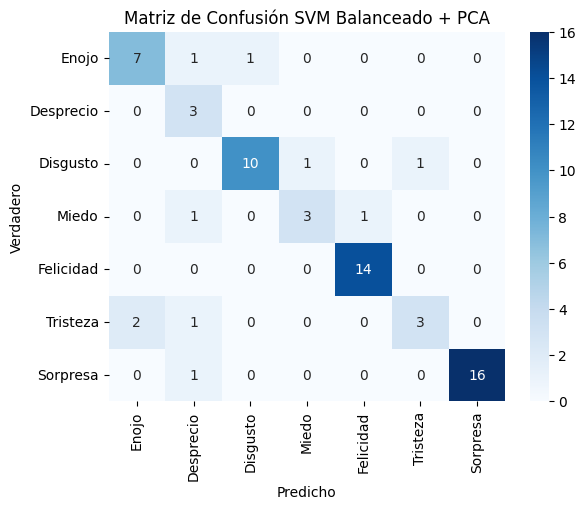

SVC(class_weight='balanced', random_state=42)

In [21]:

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=n_components, svd_solver='full', random_state=42)),
    ('svc',    SVC(kernel='rbf',
                   C=C_val,
                   gamma=gamma_val,
                   class_weight='balanced',
                   random_state=42))
])

param_grid = {
    'pca__n_components': [30],      
    'svc__C':            [0.1, 1, 10, 100,150,125,130],         
    'svc__gamma':        ['scale',0.0009, 0.0001, 0.01, 0.1]
}
grid = GridSearchCV(
    pipe, param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)
print(f"Mejor F1-weighted CV: {grid.best_score_:.4f}\n")

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Accuracy en Test:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=[emo_nom[i] for i in sorted(set(y_test))]))

cm = sns.heatmap(
    confusion_matrix(y_test, y_pred, labels=sorted(set(y_test))),
    annot=True, fmt='d',
    xticklabels=[emo_nom[i] for i in sorted(set(y_test))],
    yticklabels=[emo_nom[i] for i in sorted(set(y_test))],
    cmap='Blues'
)
plt.ylabel('Verdadero')
plt.xlabel('Predicho')
plt.title('Matriz de Confusión SVM Balanceado + PCA')
plt.show()
SVC(kernel='rbf', class_weight='balanced', random_state=42)


Tuning Decision Tree...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Decision Tree params: {'clf__criterion': 'gini', 'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'pca__n_components': 30}

Tuning Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Random Forest params: {'clf__max_depth': None, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 5, 'clf__n_estimators': 50, 'pca__n_components': 30}

=== Decision Tree ===
Accuracy en Test: 0.6667
Classification Report:
              precision    recall  f1-score   support

       Enojo       0.44      0.44      0.44         9
   Desprecio       0.17      0.33      0.22         3
    Disgusto       0.75      0.50      0.60        12
       Miedo       0.75      0.60      0.67         5
   Felicidad       0.65      0.93      0.76        14
    Tristeza       0.83      0.83      0.83         6
    Sorpresa       0.92      0

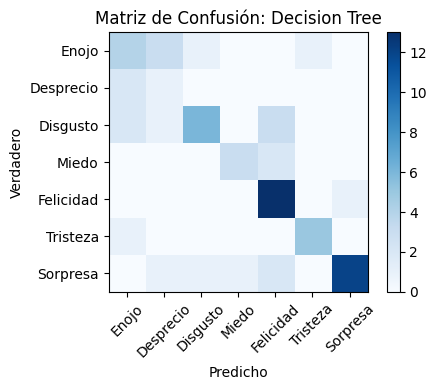


=== Random Forest ===
Accuracy en Test: 0.7424
Classification Report:
              precision    recall  f1-score   support

       Enojo       0.55      0.67      0.60         9
   Desprecio       1.00      0.33      0.50         3
    Disgusto       0.83      0.83      0.83        12
       Miedo       0.00      0.00      0.00         5
   Felicidad       0.82      1.00      0.90        14
    Tristeza       0.67      0.33      0.44         6
    Sorpresa       0.73      0.94      0.82        17

    accuracy                           0.74        66
   macro avg       0.66      0.59      0.59        66
weighted avg       0.69      0.74      0.70        66



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

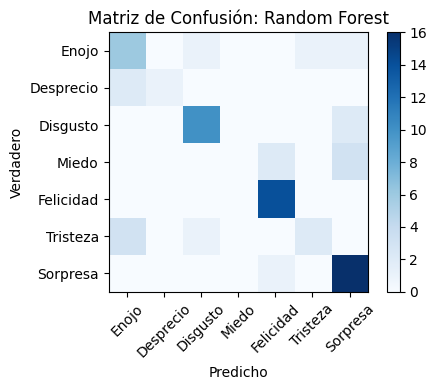

In [11]:

pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(random_state=42)),
    ('clf',    DecisionTreeClassifier(random_state=42))
])

pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(random_state=42)),
    ('clf',    RandomForestClassifier(random_state=42))
])

param_grid_dt = {
    'pca__n_components':    [30],
    'clf__max_depth':       [None, 5, 10, 20],
    'clf__min_samples_split':[2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__criterion':        ['gini', 'entropy']
}

param_grid_rf = {
    'pca__n_components':     [30],
    'clf__n_estimators':     [50, 100, 200],
    'clf__max_depth':        [None, 5, 10, 20],
    'clf__min_samples_split':[2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features':     ['sqrt', 'log2']
}

grid_dt = GridSearchCV(pipe_dt, param_grid_dt, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, scoring='accuracy', cv=5, n_jobs=-1, verbose=1)
print("Tuning Decision Tree...")
grid_dt.fit(X_train, y_train)
print("Best Decision Tree params:", grid_dt.best_params_)
print("\nTuning Random Forest...")
grid_rf.fit(X_train, y_train)
print("Best Random Forest params:", grid_rf.best_params_)
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_

for name, model in [('Decision Tree', best_dt), ('Random Forest', best_rf)]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {name} ===")
    print(f"Accuracy en Test: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=[emo_nom[i] for i in sorted(set(y_test))]
    ))
    
    cm = confusion_matrix(y_test, y_pred, labels=sorted(set(y_test)))
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusión: {name}')
    plt.colorbar()
    ticks = np.arange(len(cm))
    labels = [emo_nom[i] for i in sorted(set(y_test))]
    plt.xticks(ticks, labels, rotation=45)
    plt.yticks(ticks, labels)
    plt.xlabel('Predicho')
    plt.ylabel('Verdadero')
    plt.tight_layout()
    plt.show()
